In [1]:
from matplotlib import pyplot as plt
import matplotlib.patches as patches

In [2]:
M = 30
data_map = [
[30, 30, 31, 30, 29, 30, 31, 30],
[30, 30, 31, 30, 29, 30, 31, 30],
[29, 29, 30, 29, 29, 29, 30, 29],
[30, 30, 31, 30, 29, 30, 31, 30],
[30, 30, 31, 30, 29, 30, 31, 30],
[32, 32, 32, 32, 31, 32, 32, 32],
[30, 30, 31, 30, 29, 30, 31, 30],
[30, 30, 31, 30, 29, 30, 31, 30]
]

In [3]:
def solution(M, data_map):
    
    # ----------------------------------------------------------
    plt.clf()
    plt.figure()
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.xlim([0, 9])
    plt.ylim([0, 9])
    plt.xticks([], [])
    plt.yticks([], [])
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    
    for j in range(8):
        for i in range(8):
            ax.add_patch(
                patches.Rectangle(
                (i, 8-j),
                0.8, 0.8,
                edgecolor = 'black',
                facecolor = 'white',
                fill=True,
            ))
            ax.text(i+0.2, 8-j+0.3, data_map[j][i])
    plt.savefig('1.png', dpi=500)
    # --------------------------------------------------------
    
    # 기본값씩 빼기
    for i in range(len(data_map)):
        data_map[i] = list(map(lambda x: x-M, data_map[i]))
        
    # ----------------------------------------------------------
    plt.clf()
    plt.figure()
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.xlim([0, 9])
    plt.ylim([0, 9])
    plt.xticks([], [])
    plt.yticks([], [])
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    
    for j in range(8):
        for i in range(8):
            ax.add_patch(
                patches.Rectangle(
                (i, 8-j),
                0.8, 0.8,
                edgecolor = 'black',
                facecolor = 'white',
                fill=True,
            ))
            ax.text(i+0.2, 8-j+0.3, data_map[j][i])
    plt.savefig('2.png', dpi=500)
    # --------------------------------------------------------
    
    # 인덱스마다 십자합
    # 인덱스의 십자합 값 ->
    # + (행에 존재하는 비료분무기의 수) * 8
    # + (열에 존재하는 비료분무기의 수) * 8
    # - (행에 존재하는 제초분무기의 수) * 8
    # - (열에 존재하는 제초분무기의 수) * 8
    # + (행, 열에 존재하지 않는 비료분무기의 수) * 2
    # - (행, 열에 존재하지 않는 제초분무기의 수) * 2
    # - (해당 위치에 비료분무기가 존재하면 1)
    # + (해당 위치에 제초분무기가 존재하면 1)
    # 홀수인 부분에 비료분무기 혹은 제초분무기 존재
    # -> 하나의 위치에는 비료분무기(-1) 혹은 제초분무기(+1) 혹은 둘다 없음(0) 밖에 없기 때문

    sum_map = [[0 for _ in range(8)] for __ in range(8)]
    for i in range(8):
        sum_row = sum(data_map[i])
        for j in range(8):
            sum_column = sum([data_map[ii][j] for ii in range(8)])
            sum_map[i][j] = sum_row + sum_column - data_map[i][j]
    
    # ----------------------------------------------------------
    plt.clf()
    plt.figure()
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.xlim([0, 9])
    plt.ylim([0, 9])
    plt.xticks([], [])
    plt.yticks([], [])
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    
    for j in range(8):
        for i in range(8):
            color = 'blue' if sum_map[j][i] % 2 else 'black'
            ax.add_patch(
                patches.Rectangle(
                (i, 8-j),
                0.8, 0.8,
                edgecolor = color,
                facecolor = 'white',
                fill=True,
            ))
            ax.text(i+0.2, 8-j+0.3, sum_map[j][i])
    plt.savefig('3.png', dpi=500)
    # --------------------------------------------------------
    
    # 분무기의 위치
    target_idxs = [[i, j] for j in range(8) for i in range(8) if sum_map[i][j]%2]

    # 모두 비료분무기라고 가정하고 맵을 재구성
    all_pos_map = [[30 for _ in range(8)] for __ in range(8)]
    for x, y in target_idxs:
        for i in range(8):
            for j in range(8):
                if i == x or j == y:
                    all_pos_map[i][j] += 1
    
    # ----------------------------------------------------------
    plt.clf()
    plt.figure()
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.xlim([0, 9])
    plt.ylim([0, 9])
    plt.xticks([], [])
    plt.yticks([], [])
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    
    for j in range(8):
        for i in range(8):
            ax.add_patch(
                patches.Rectangle(
                (i, 8-j),
                0.8, 0.8,
                edgecolor = 'black',
                facecolor = 'white',
                fill=True,
            ))
            ax.text(i+0.2, 8-j+0.3, all_pos_map[j][i])
    plt.savefig('4.png', dpi=500)
    # --------------------------------------------------------
    
    # 실제 맵과 가정한 맵의 차이
    for i in range(8):
        for j in range(8):
            all_pos_map[i][j] -= data_map[i][j] + 30
    
    # ----------------------------------------------------------
    plt.clf()
    plt.figure()
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.xlim([0, 9])
    plt.ylim([0, 9])
    plt.xticks([], [])
    plt.yticks([], [])
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    
    for j in range(8):
        for i in range(8):
            ax.add_patch(
                patches.Rectangle(
                (i, 8-j),
                0.8, 0.8,
                edgecolor = 'black',
                facecolor = 'white',
                fill=True,
            ))
            ax.text(i+0.2, 8-j+0.3, all_pos_map[j][i])
    plt.savefig('5.png', dpi=500)
    # --------------------------------------------------------
    
    
    # 타겟 인덱스마다 십자합
    # 타겟 인덱스의 십자합 값 ->
    # 자신이 원래 비료분무기인데 다른 타겟이 비료분무기가 아니었을 경우
    # 같은 행, 열에 존재하면 타겟 십자합에서 개당 16씩((1 - (-1))x8),
    # 다른 행, 열에 존재하면 타겟 십자합에서 개당 4씩((1 - (-1))x2) 빼짐
    # 자신이 비료분무기가 아닌 경우
    # 위의 값에서 30씩((1 - (-1)x15) 가 빠짐
    # 즉 십자합이 4 의 배수면 자신은 비료분무기
    # 4의 배수가 아니면 제초분무기

    all_sum_map = [[0 for _ in range(8)] for __ in range(8)]
    for i in range(8):
        sum_row = sum(all_pos_map[i])
        for j in range(8):
            sum_column = sum([all_pos_map[ii][j] for ii in range(8)])
            all_sum_map[i][j] = sum_row + sum_column - all_pos_map[i][j]
    
    # ----------------------------------------------------------
    plt.clf()
    plt.figure()
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.xlim([0, 9])
    plt.ylim([0, 9])
    plt.xticks([], [])
    plt.yticks([], [])
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    
    for j in range(8):
        for i in range(8):
            color = 'blue' if [i, j] in target_idxs and not all_sum_map[i][j] % 4 else 'red' if [i, j] in target_idxs else 'black'
            ax.add_patch(
                patches.Rectangle(
                (j, 8-i),
                0.8, 0.8,
                edgecolor = color,
                facecolor = 'white',
                fill=True,
            ))
            ax.text(i+0.2, 8-j+0.3, all_sum_map[j][i])
    plt.savefig('6.png', dpi=500)
    # --------------------------------------------------------
    
    
    symbols = ['--' if all_sum_map[i][j]%4 else '+' for i, j in target_idxs]
    
    symbol_map = [['.' for _ in range(8)] for __ in range(8)]
    for [i, j], symbol in zip(target_idxs, symbols):
        symbol_map[i][j] = symbol
    
    for i in range(8):
        print(*symbol_map[i])
        
    # ----------------------------------------------------------
    plt.clf()
    plt.figure()
    fig, ax = plt.subplots(figsize=(10, 10))
    plt.xlim([0, 9])
    plt.ylim([0, 9])
    plt.xticks([], [])
    plt.yticks([], [])
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['left'].set_visible(False)
    plt.gca().spines['bottom'].set_visible(False)
    
    for j in range(8):
        for i in range(8):
            color = 'blue' if [i, j] in target_idxs and not all_sum_map[i][j] % 4 else 'red' if [i, j] in target_idxs else 'black'
            ax.add_patch(
                patches.Rectangle(
                (j, 8-i),
                0.8, 0.8,
                edgecolor = color,
                facecolor = 'white',
                fill=True,
            ))
            ax.text(i+0.2, 8-j+0.3, symbol_map[j][i])
    plt.savefig('7.png', dpi=500)
    # --------------------------------------------------------

. . . . . . . .
. . . . . . . .
. . . . -- . . .
. . . . . . . .
. . . . . . . .
. . + . . . + .
. . . . . . . .
. . . . . . . .


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 640x480 with 0 Axes>

...

<Figure size 640x480 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

<Figure size 640x480 with 0 Axes>

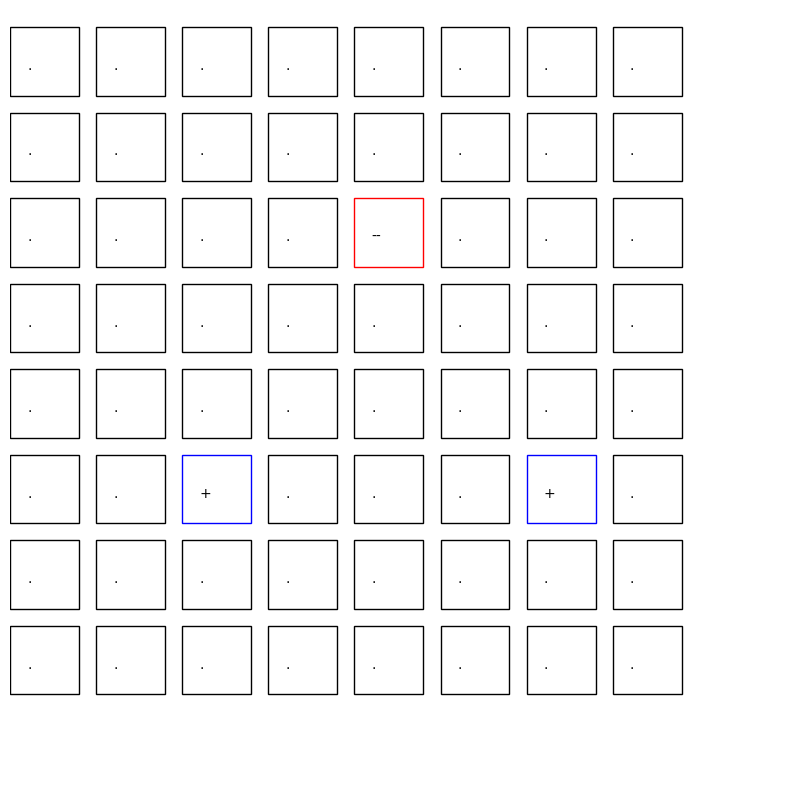

In [4]:
solution(M, data_map)